## 📌 Introduction

This notebook focuses on the **data exploration phase** . The main objectives of this exploration are to:

- Understand the overall structure and size of the dataset  
- Identify attribute types and key features  
- Assess data quality issues such as missing, inconsistent, or extreme values  
- Generate descriptive statistics for numerical and categorical attributes  
- Visualize data distributions and basic relationships between variables  
- Document initial observations to inform later preprocessing and data mining tasks  

At this stage, no data cleaning, transformation, or mining techniques are applied. The goal is solely to **understand the data** and prepare for subsequent analysis.


In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from pathlib import Path
from datetime import datetime

PROJECT_ROOT = Path('..').resolve()
RAW_DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'Driving Data(KIA SOUL)_(150728-160714)_(10 Drivers_A-J).csv'
CLEANED_DATA_PATH = PROJECT_ROOT / 'data' / 'cleaned' / 'Driving Data(KIA SOUL)_(150728-160714)_(10 Drivers_A-J)_cleaned.csv'
CHANGE_LOG_PATH = PROJECT_ROOT / 'results' / 'data_cleaning_change_log.txt'
CLEANED_FEATURES_PATH = PROJECT_ROOT / 'data' / 'cleaned' / 'Driving_Data_Selected_Features_Risky_Label.csv'
TRANSFORMED_DATA_PATH = PROJECT_ROOT / 'data' / 'transformed' / 'Driving_Data_With_Risky_Label.csv'


sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
np.random.seed(42)
df = pd.read_csv("../data/raw/Driving Data(KIA SOUL)_(150728-160714)_(10 Drivers_A-J).csv")


display(df['Fuel_Pressure'])

sampled_df = df.groupby("Class").apply(lambda x: x.sample(n=5, random_state=1)).reset_index(drop=True)

df_sorted = df.sort_values(by="Time(s)", ascending=True)
df_sorted_id = df.sort_values(by="Class", ascending=True)


class_counts = df["Engine_in_fuel_cut_off"].value_counts()
print(class_counts)



0        0
1        0
2        0
3        0
4        0
        ..
94375    0
94376    0
94377    0
94378    0
94379    0
Name: Fuel_Pressure, Length: 94380, dtype: int64

Engine_in_fuel_cut_off
0    88033
1     6347
Name: count, dtype: int64


C:\Users\idris\AppData\Local\Temp\ipykernel_4596\870770509.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby("Class").apply(lambda x: x.sample(n=5, random_state=1)).reset_index(drop=True)




Each driver (A–J) has many rows because the data are recorded continuously over time. Each row represents sensor readings at a specific time instant, not a unique driver. Therefore, a single driver generates thousands of samples corresponding to different driving situations.



## 🛢️ Fuel & Air Management

- **Fuel_consumption:** Engine fuel usage, used to assess efficiency and emissions.

        Type : continuous and vals : [0.0, 10931.2]
- **Fuel_Pressure:** Fuel pressure supplied to injectors, affecting combustion quality.

        all values are 0 , lapobel 🗑️
- **Intake_air_pressure:** Air pressure entering the engine, indicating engine load.

        Type : discrete and vals :  [0, 178]

- **Calculated_LOAD_value:** Estimated engine load based on airflow and RPM (how hard the engine is working at a given moment).

        It is calculated by the ECU (Engine Control Unit) using inputs such as:
            . Airflow into the engine (Intake air pressure)
            . Engine speed (RPM)
            . Throttle position
            . Fuel injection or fuel pressure

        Type : continuous and vals : [0.0, 98.4]

## 🦶 Driver Input & Throttle (controls how much air enters the engine)

- **Accelerator_Pedal_value:** Raw accelerator pedal position showing driver demand.

        Type : continous and vals :  [0.0, 99.2]

- **Filtered_Accelerator_Pedal_value:** Smoothed accelerator signal for stable control(Accelerator_Pedal_value with filtering ).

        all values are 0 so 🗑️

- **Throttle_position_signal:** Throttle opening signal controlling air intake.

        Type : continuous and vals : [0.0, 100.0] 

- **Absolute_throttle_position:** Actual throttle plate position(physical angle of the throttle plate).

        Type : continuous and vals : [12.5, 84.3]


## 🔥 Fuel Trim & Combustion

    Term_Fuel : air–fuel mixture to be just right .
        - Air–fuel ratio (AFR) = ratio of air to fuel in the engine.
        - If it’s off, the ECU adjusts the fuel using fuel trims.

- **Short_Term_Fuel_Trim_Bank1:** Short-term fuel correction for air–fuel ratio control.

        Type : continuous and vals : [-15.6, 23.4]

- **Long_Term_Fuel_Trim_Bank1:** Long-term fuel correction compensating persistent deviations.

        Type : continuous and vals : [-1.6, 10.2]


- **Current_spark_timing:** Ignition timing affecting power and efficiency.

        Type : continuous and vals : [-35.6, 50.3]

## 🧠 Engine State

- **Engine_speed:** Engine speed in RPM(Revolutions Per Minute).

        Type : discrete and vals : [0, 6253]

- **Engine_Idel_Target_Speed:** Target RPM during idle.

        Type : discrete and vals : [0, 1550]

- **Engine_soacking_time:** Time engine remains heat-soaked after shutdown.

        Type : discrete and vals : [0, 255] (minutes)

- **Engine_coolant_temperature:** Engine coolant temperature indicating thermal state.

        temperature of the engine coolant (the liquid that circulates inside the engine to remove heat) , tell how cold or hot the engin is .

        Type : discrete and vals : [-40, 96] (°C)

- **Engine_coolant_temperature.1:** Redundant coolant temperature measurement(not duplicate , it has different values).
        Type : discrete and vals : [-40, 105] (°C)

## ⚙️ Torque & Power

- **Engine_torque:** Torque (Force) produced by the engine(theoretical torque engine).

        Type : continuous and vals :[0.0, 83.6] (Newton-meters (N·m))

- **Engine_torque_after_correction:** Engine torque after ECU corrections(Engine Control Unit)like for slipping wheels it will reduce the force.

        Same type and values .

- **Minimum_indicated_engine_torque:** Minimum allowed engine torque.

        Type : continuous and vals : [0.0, 8.2]

- **Maximum_indicated_engine_torque:** Maximum achievable engine torque.

        Type : Continuous and vals : [0.0, 91.4]

- **Torque_of_friction:** Torque lost to internal engine friction.

        Type : continuous and vals : [0.0, 28.1]

- **Flywheel_torque:** Torque at the engine flywheel(actual torque engine).

        Type : continuous and vals :  [-47.5, 158.4]

- **Flywheel_torque_(after_torque_interventions):** Flywheel torque after ECU interventions.

        Same values and type

- **Torque_scaling_factor(standardization):** Scaling factor used to normalize torque values.

        all values 230 (int) probably 🗑️.


- **Standard_Torque_Ratio:** Ratio of current torque to reference torque(how hard the engine is working compared to its normal or maximum capability).

        Type : binary and vals : [0, 1] (it is a ration but we only get two value 0  or one )so in this case the info we get is : is the engine deliver the max torque or not . 
        

## 🛑 Fuel Cut-off & Protection

        Fuel cut-off : stop injecting fuel when it’s not needed

- **Inhibition_of_engine_fuel_cut_off:** Indicates fuel cut-off inhibition status(disabled or allowed).

        all values are 0  , so probably 🗑️.

- **Engine_in_fuel_cut_off:** Indicates active fuel cut-off during deceleration(wether currently not injecting fuel).

        Type : binary vals 

## 🔁 Transmission & Converter

- **Current_Gear:** Currently engaged gear.

        Type : discrete and vals : [0, 14]

- **Gear_Selection:** Selected gear by driver or system.

        Type : discrete and vals : [0, 15]

- **Torque_converter_speed:** Speed of the torque converter.

        Type : continuous and vals : [0.0, 6234.0](RPM)

- **Torque_converter_turbine_speed_Unfiltered:** Raw turbine speed measurement.

        Type : continuous and vals : [0.0,6236.5](RPM)

- **Converter_clutch:** Torque converter lock-up clutch state(disengaged, engaged or sliped (partially engaged)).

        Type : discrete and vals :  [0, 2]

- **Clutch_operation_acknowledge:** Acknowledgement of clutch operation (yer or no ).

        Type : binary  and vals :  [0, 2]

## 🚗 Vehicle Dynamics

- **Vehicle_speed:** Vehicle speed.

        Type : discrete and vals : [0, 129]

- **Wheel_velocity_front_left-hand:** Front-left wheel speed.

        Type : continuous and vals : [0.0, 135.1]

- **Wheel_velocity_front_right-hand:** Front-right wheel speed.

        Type : continuous and vals :[0.0, 133.9]


- **Wheel_velocity_rear_left-hand:** Rear-left wheel speed.

        Type : continuous and vals :[0.0, 134.1]

- **Wheel_velocity_rear_right-hand:** Rear-right wheel speed.

        Type : continuous and vals :[0.0, 133.2]

- **Acceleration_speed_Longitudinal:** Longitudinal acceleration or deceleration.

        Type : continuous and vals : [-10.2, 8.1]

- **Acceleration_speed_Lateral:** Lateral acceleration during cornering.

        Type : continuous and vlas : [-10.2, 8.1]

## 🧭 Steering & Road

- **Steering_wheel_angle:** Steering wheel angle.

        Type : continuous and vals [-516.8, 530.3]

- **Steering_wheel_speed:** Rate of steering input.

        Type : discrete and vals :[0, 632]

- **Calculated_road_gradient:** Estimated road slope.

        Type : continuous and vals : [-16.0, 15.5]

## 🛑 Braking

- **Indication_of_brake_switch_ON/OFF:** Brake pedal status.

        Type : binary and vals [0, 2] (2 can indicate on invalid/unknown)

- **Master_cylinder_pressure:** Brake hydraulic pressure.

        Type : continuous and vals : [0.0, 395.9] (unit bar)

## ❄️ Auxiliary

- **Glow_plug_control_request:** Glow plug activation request.

        all values are 0

- **Activation_of_Air_compressor:** Air conditioning compressor status.

        Type : binary and values 0 or 1

## 🧠 ECU / TCU Requests

- **Requested_spark_retard_angle_from_TCU:** Spark retard requested by transmission.

        Type : discrete and vals :  [-15, 15]

- **TCU_requests_engine_torque_limit_(ETL):** Engine torque limit request from TCU.

        Type : discrete and vals : [0, 508]

- **TCU_requested_engine_RPM_increase:** Request to increase engine RPM.

        Type : continuous  and vals : [0.0, 21.1]

- **Target_engine_speed_used_in_lock-up_module:** Target RPM for torque converter lock-up.

        type :  countinuous and vals  [500, 3040]


## 🕒 Metadata

- **Time(s):** Time stamp in seconds.

        Type : discrete and vals [1, 2948]

- **Class:** Driver IDs (10).

        Vals : [A, J] where for each driver we have : 
                
                D    13244
                B    12864
                F    11012
                H     9880
                J     8904
                E     8436
                I     7808
                C     7500
                G     7492
                A     7240
                        

- **PathOrder:** Trip or path sequence identifier (first path or second path ).

        vals : [1, 2]




In [8]:
print('Shape:', df.shape)
print('\nInfo:')
df.info()



Shape: (94380, 54)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94380 entries, 0 to 94379
Data columns (total 54 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Fuel_consumption                              94380 non-null  float64
 1   Accelerator_Pedal_value                       94380 non-null  float64
 2   Throttle_position_signal                      94380 non-null  float64
 3   Short_Term_Fuel_Trim_Bank1                    94380 non-null  float64
 4   Intake_air_pressure                           94380 non-null  int64  
 5   Filtered_Accelerator_Pedal_value              94380 non-null  int64  
 6   Absolute_throttle_position                    94380 non-null  float64
 7   Engine_soacking_time                          94380 non-null  int64  
 8   Inhibition_of_engine_fuel_cut_off             94380 non-null  int64  
 9   Engine_in_fuel_cut_off             

In [9]:
df_eda = df.copy()
print('\nNumeric summary:')
display(df_eda.describe())

print("Missing values per column:")
display(df_eda.isnull().sum())



Numeric summary:


,Fuel_consumption,Accelerator_Pedal_value,Throttle_position_signal,Short_Term_Fuel_Trim_Bank1,Intake_air_pressure,Filtered_Accelerator_Pedal_value,Absolute_throttle_position,Engine_soacking_time,Inhibition_of_engine_fuel_cut_off,Engine_in_fuel_cut_off,Fuel_Pressure,Long_Term_Fuel_Trim_Bank1,Engine_speed,Engine_torque_after_correction,Torque_of_friction,Flywheel_torque_(after_torque_interventions),Current_spark_timing,Engine_coolant_temperature,Engine_Idel_Target_Speed,Engine_torque,Calculated_LOAD_value,Minimum_indicated_engine_torque,Maximum_indicated_engine_torque,Flywheel_torque,Torque_scaling_factor(standardization),...,TCU_requested_engine_RPM_increase,Target_engine_speed_used_in_lock-up_module,Glow_plug_control_request,Activation_of_Air_compressor,Torque_converter_speed,Current_Gear,Engine_coolant_temperature.1,Wheel_velocity_front_left-hand,Wheel_velocity_rear_right-hand,Wheel_velocity_front_right-hand,Wheel_velocity_rear_left-hand,Torque_converter_turbine_speed_-_Unfiltered,Clutch_operation_acknowledge,Converter_clutch,Gear_Selection,Vehicle_speed,Acceleration_speed_-_Longitudinal,Indication_of_brake_switch_ON/OFF,Master_cylinder_pressure,Calculated_road_gradient,Acceleration_speed_-_Lateral,Steering_wheel_speed,Steering_wheel_angle,Time(s),PathOrder
count,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.0,94380.000000,94380.000000,94380.0,94380.000000,94380.0,94380.000000,94380.000000,94380.000000,94380.00000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.00000,94380.000000,94380.000000,94380.000000,94380.0,...,94380.000000,94380.000000,94380.0,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000
mean,757.000246,3.718682,13.208186,0.122782,36.853433,0.0,19.362277,26.795327,0.0,0.067249,0.0,2.843127,1422.838885,23.813976,13.69958,22.820449,10.506642,84.346800,895.345624,23.757734,42.30515,1.946885,67.572107,22.738693,230.0,...,0.136569,3039.919263,0.0,0.890581,1259.509722,3.250085,84.615628,30.113410,29.209106,29.362165,29.901012,1259.950517,0.627792,0.612810,4.877474,28.518881,-0.076198,1.356294,5.686715,0.300419,-0.007616,6.362407,0.773593,1110.031765,1.513583
std,761.376214,8.505756,16.262249,3.166412,27.957584,0.0,12.079046,73.072712,0.0,0.250455,0.0,1.362755,613.428059,14.633545,2.27353,36.523296,13.401414,6.140172,178.836264,14.733961,18.38917,0.694589,9.576038,36.745301,0.0,...,1.266017,14.320222,0.0,0.312166,766.150141,2.149919,13.639351,26.480625,26.107705,26.223972,26.315974,766.265828,0.483396,0.847272,0.936442,25.309664,0.593006,0.479017,9.904240,2.210411,0.417956,26.467043,60.815388,683.042550,0.499818
min,0.000000,0.000000,0.000000,-15.600000,0.000000,0.0,12.500000,0.000000,0.0,0.000000,0.0,-1.600000,0.000000,0.000000,0.00000,-47.500000,-35.600000,-40.000000,0.000000,0.000000,0.00000,0.000000,0.000000,-47.500000,230.0,...,0.000000,500.000000,0.0,0.000000,0.000000,0.000000,-40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-10.200000,0.000000,0.000000,-16.000000,-10.200000,0.000000,-516.800000,1.000000,1.000000
25%,320.000000,0.000000,6.600000,-1.600000,4.000000,0.0,14.500000,1.000000,0.0,0.000000,0.0,2.300000,823.000000,14.800000,12.50000,0.300000,-1.500000,84.000000,800.000000,14.800000,27.10000,2.000000,57.000000,0.300000,230.0,...,0.000000,3040.000000,0.0,1.000000,668.800000,1.000000,83.000000,4.500000,3.900000,4.000000,4.400000,669.300000,0.000000,0.000000,5.000000,4.000000,-0.300000,1.000000,1.000000,0.000000,-0.100000,0.000000,-2.600000,537.000000,1.000000
50%,422.400000,0.000000,7.500000,0.000000,38.000000,0.0,15.300000,3.000000,0.0,0.000000,0.0,3.100000,1473.000000,20.300000,13.70000,12.700000,6.800000,85.000000,900.000000,20.300000,41.60000,2.000000,69.500000,12.900000,230.0,...,0.0

Missing values per column:


Fuel_consumption                                0
Accelerator_Pedal_value                         0
Throttle_position_signal                        0
Short_Term_Fuel_Trim_Bank1                      0
Intake_air_pressure                             0
Filtered_Accelerator_Pedal_value                0
Absolute_throttle_position                      0
Engine_soacking_time                            0
Inhibition_of_engine_fuel_cut_off               0
Engine_in_fuel_cut_off                          0
Fuel_Pressure                                   0
Long_Term_Fuel_Trim_Bank1                       0
Engine_speed                                    0
Engine_torque_after_correction                  0
Torque_of_friction                              0
Flywheel_torque_(after_torque_interventions)    0
Current_spark_timing                            0
Engine_coolant_temperature                      0
Engine_Idel_Target_Speed                        0
Engine_torque                                   0


## Possible Otliers

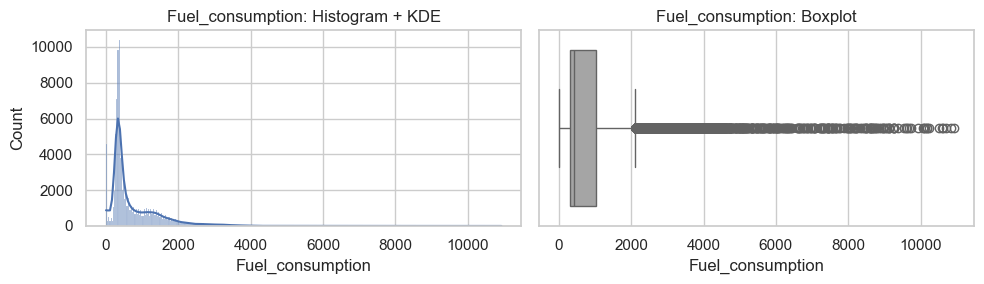

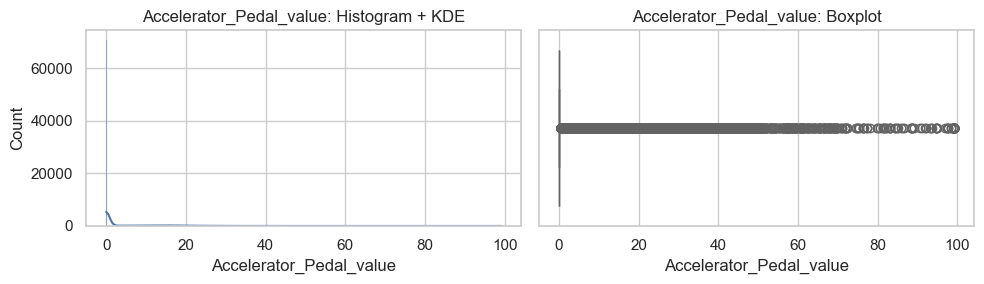

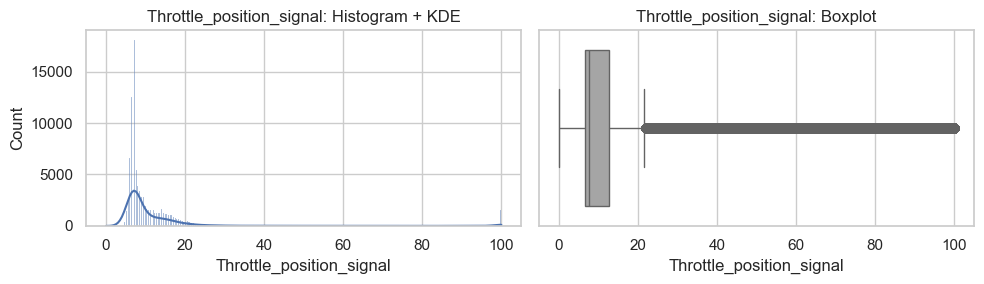

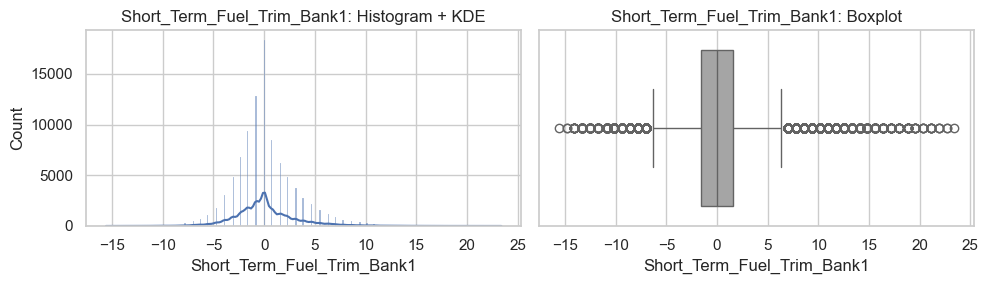

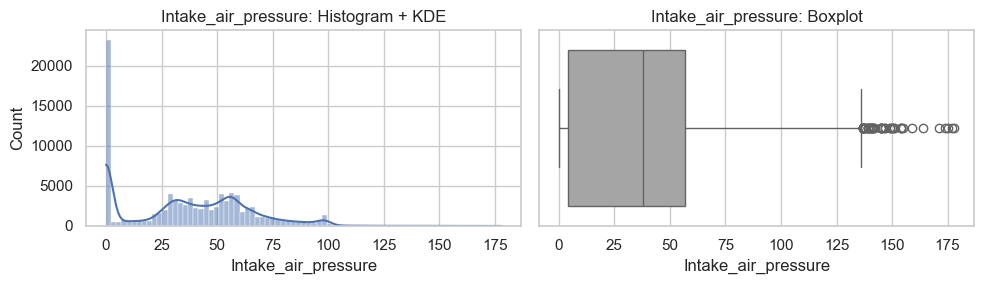

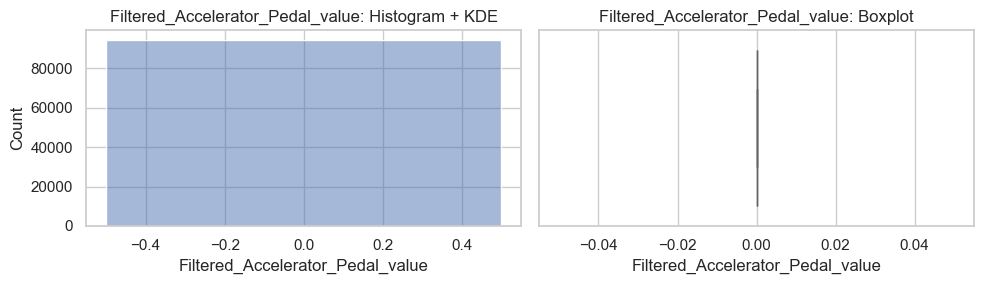

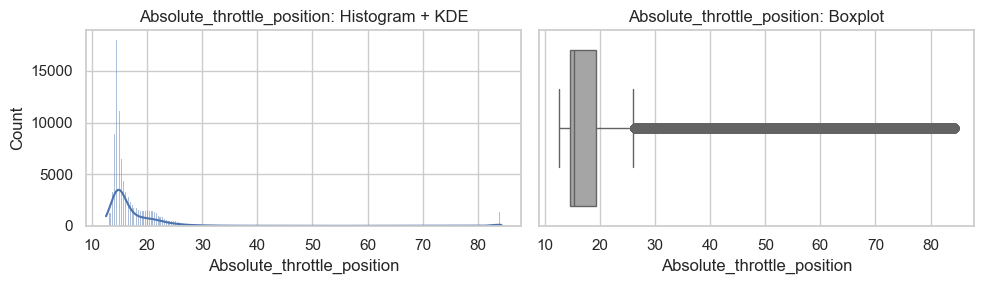

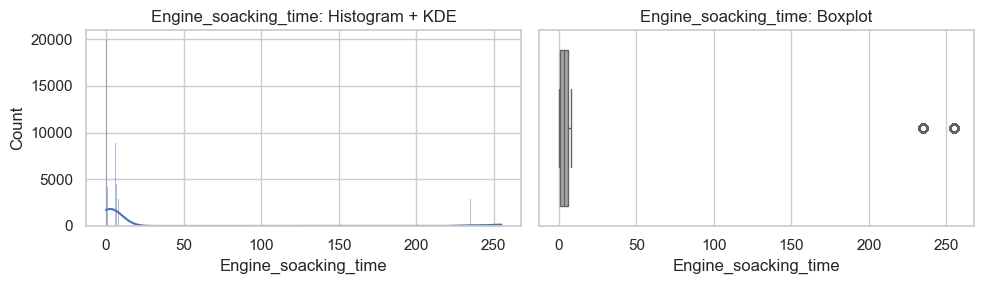

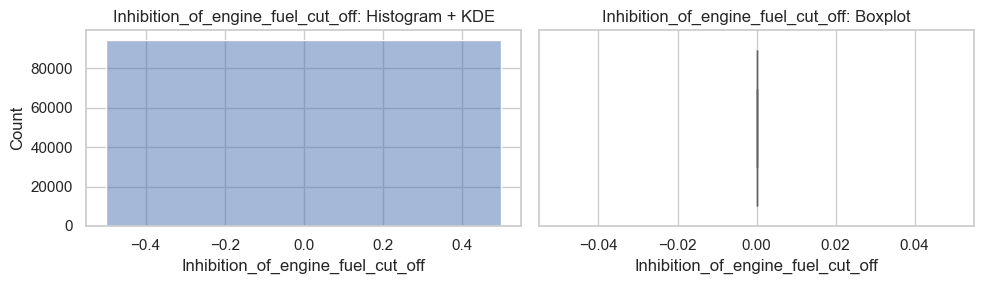

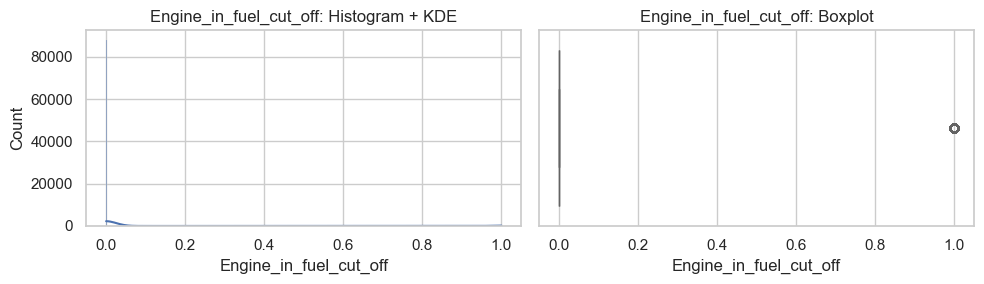

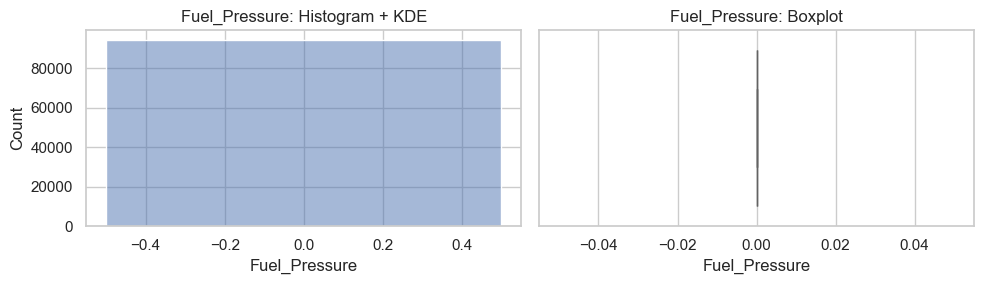

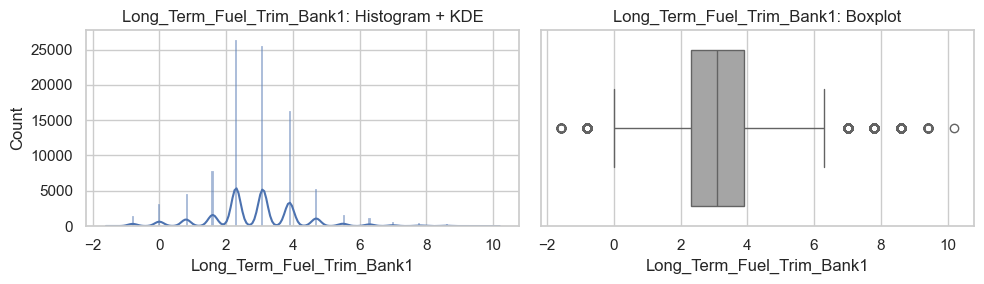

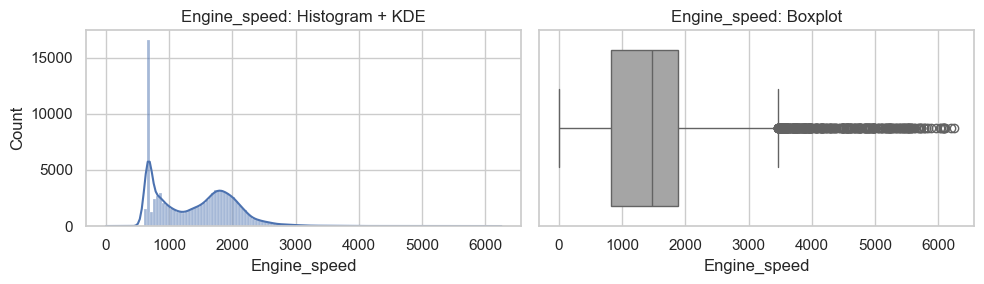

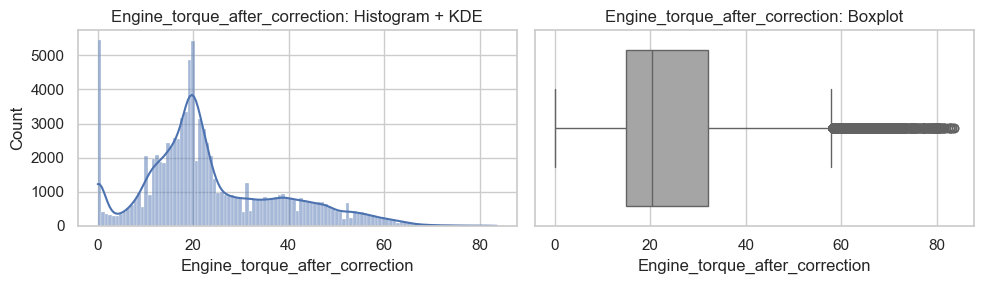

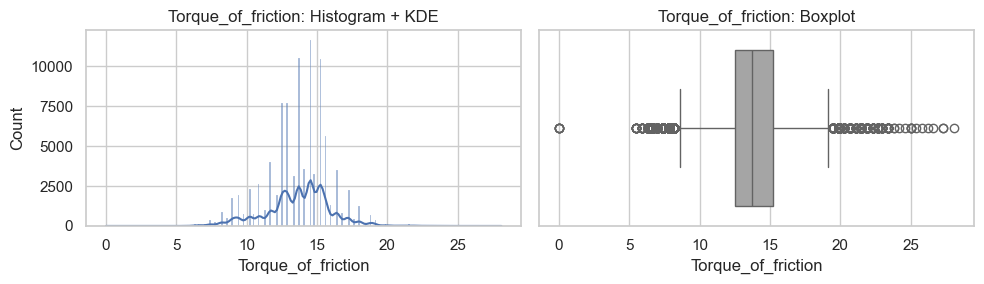

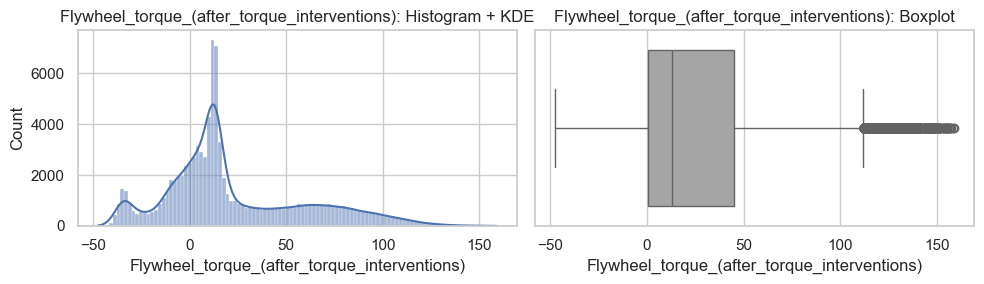

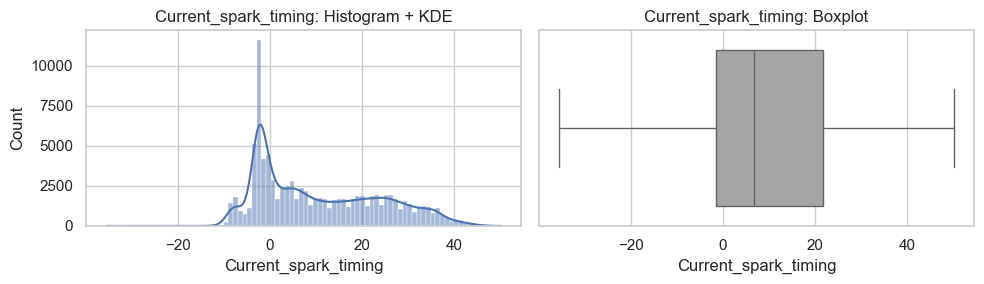

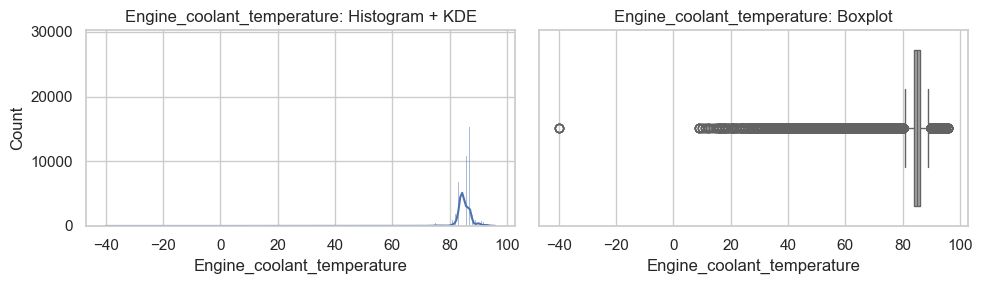

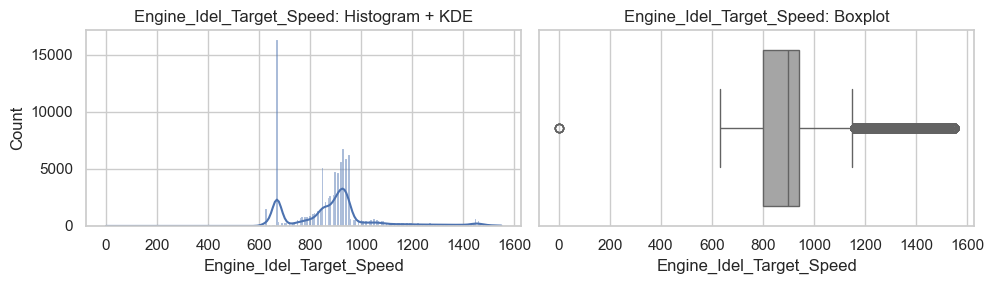

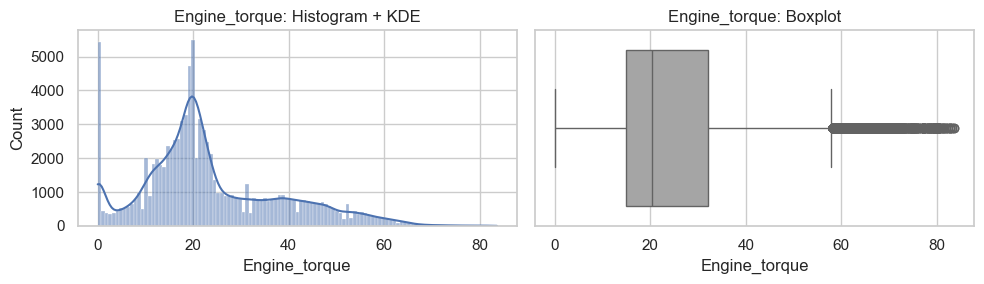

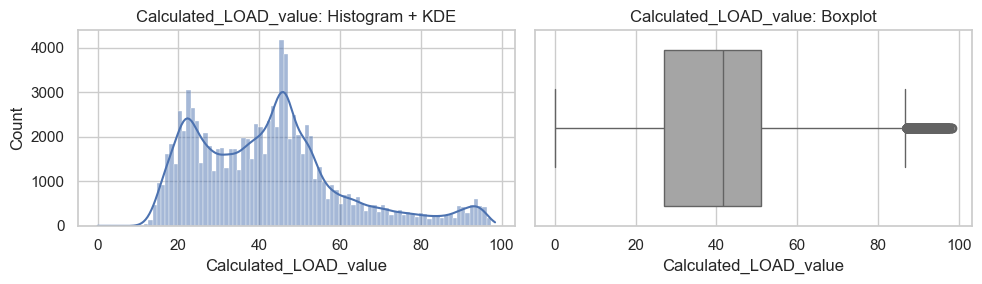

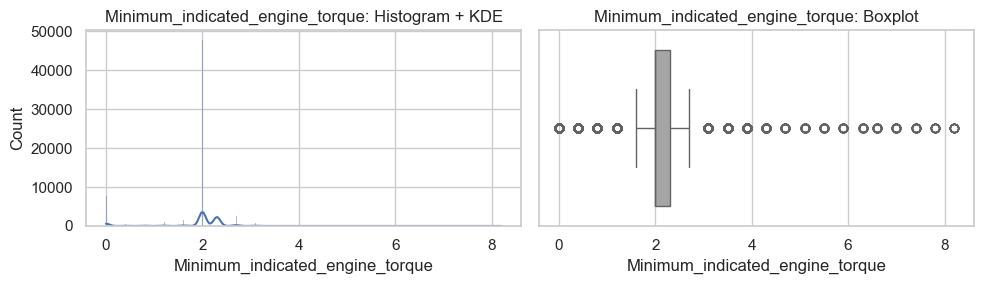

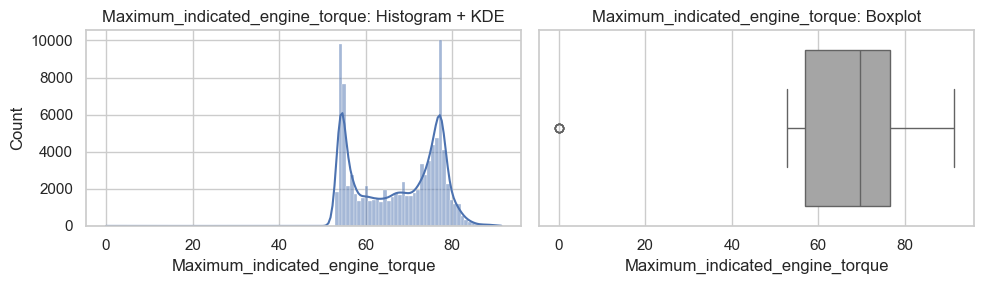

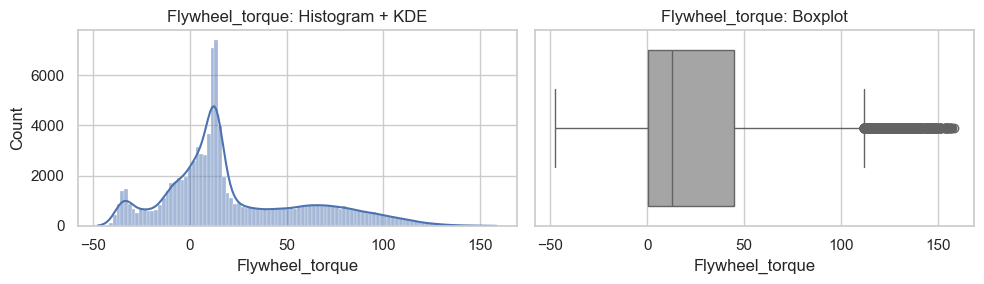

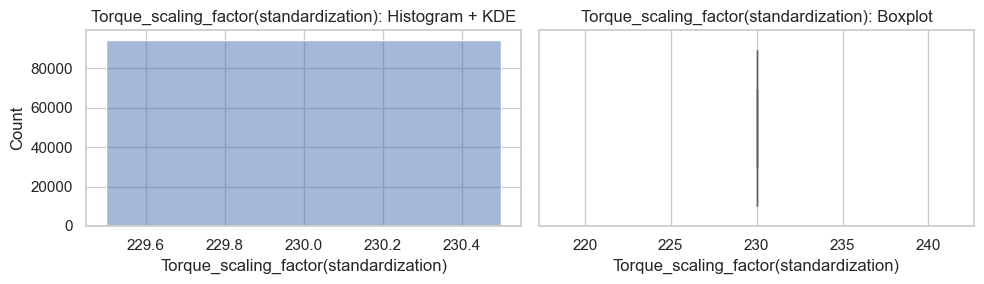

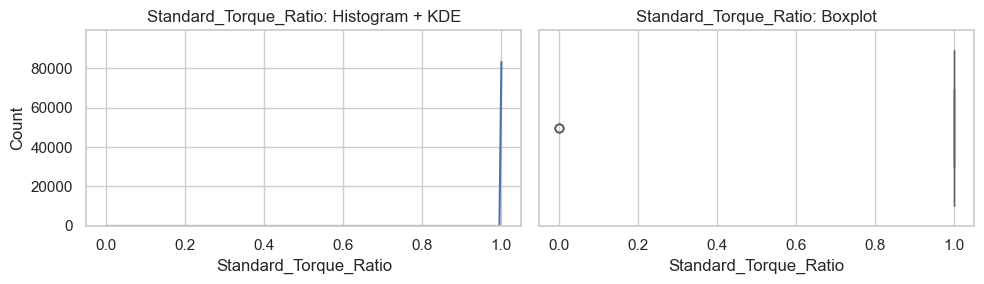

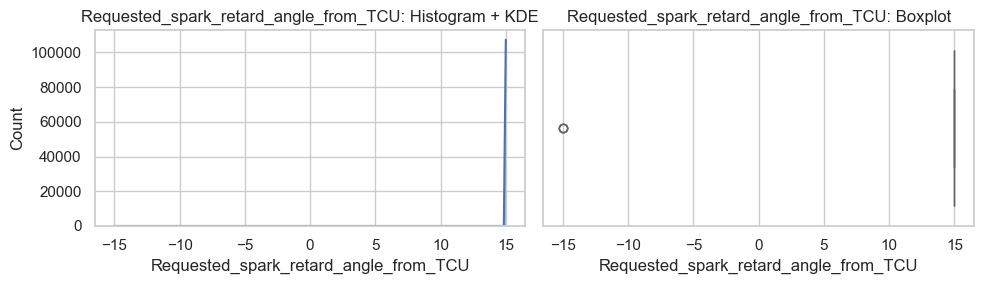

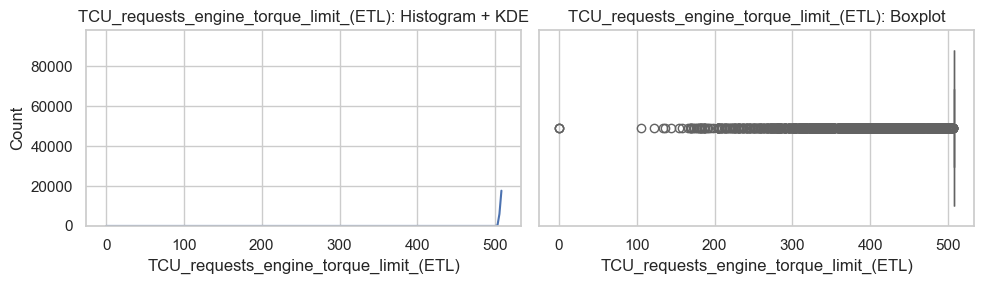

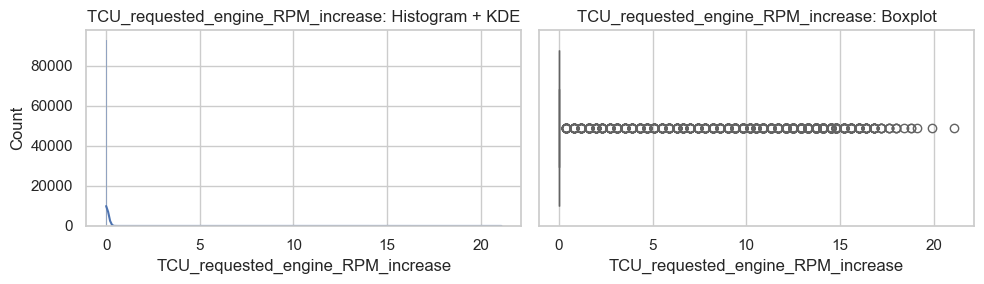

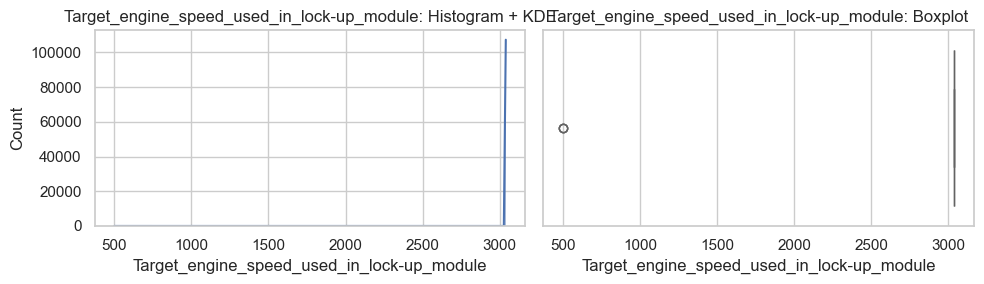

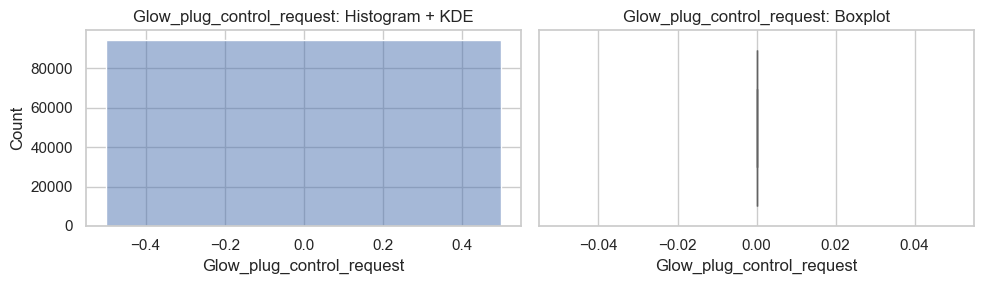

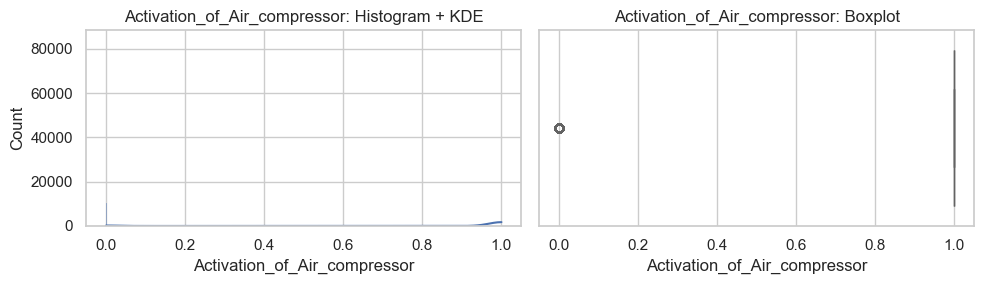

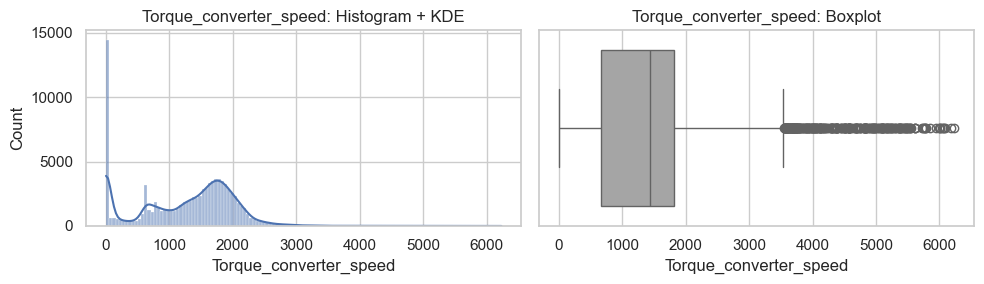

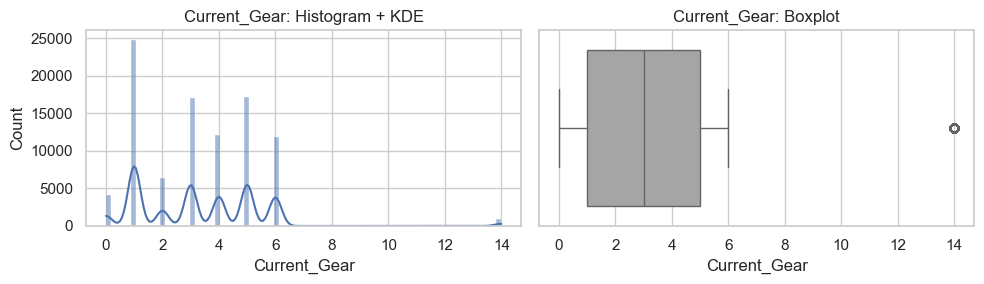

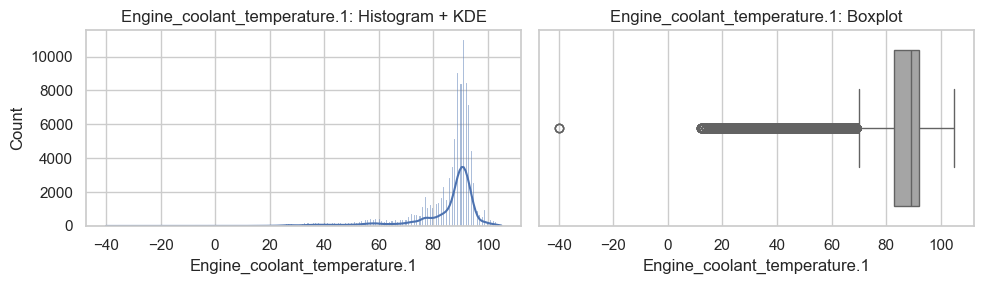

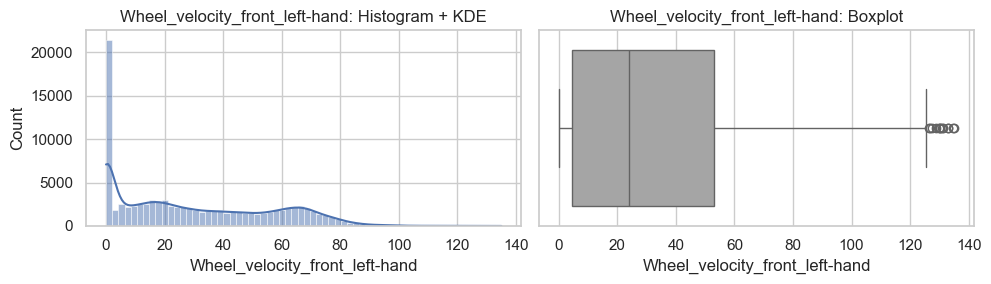

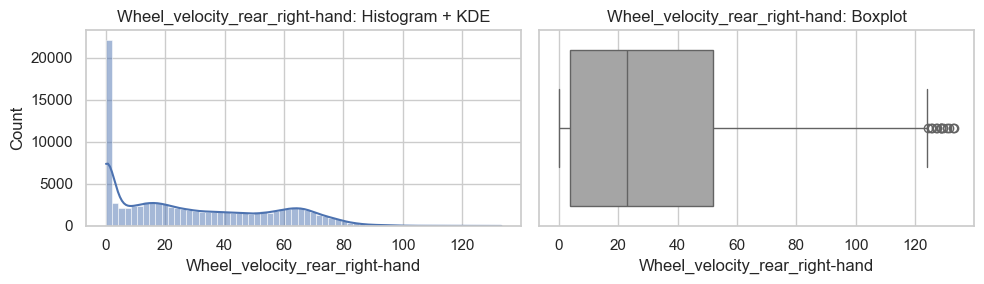

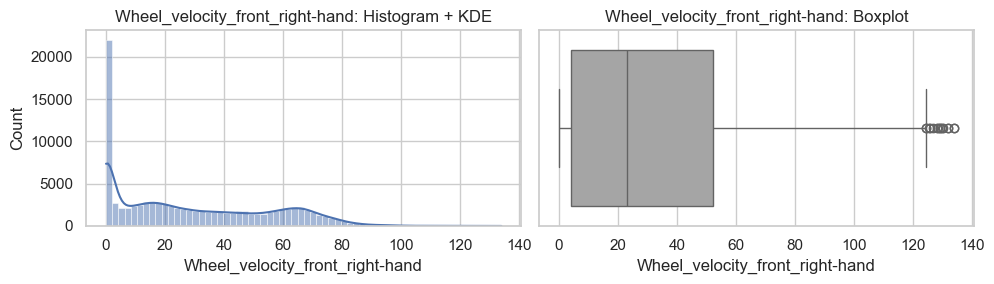

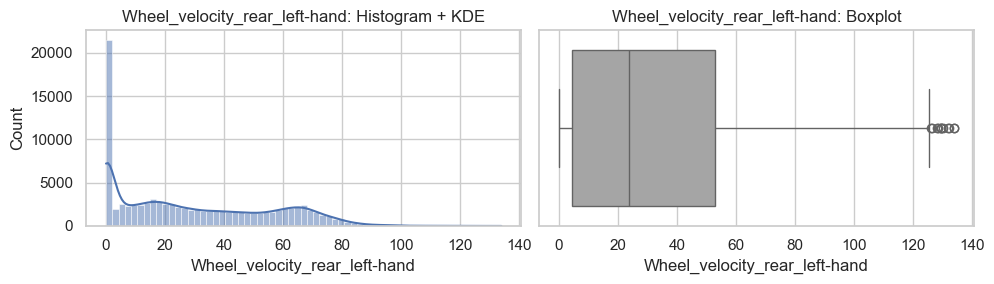

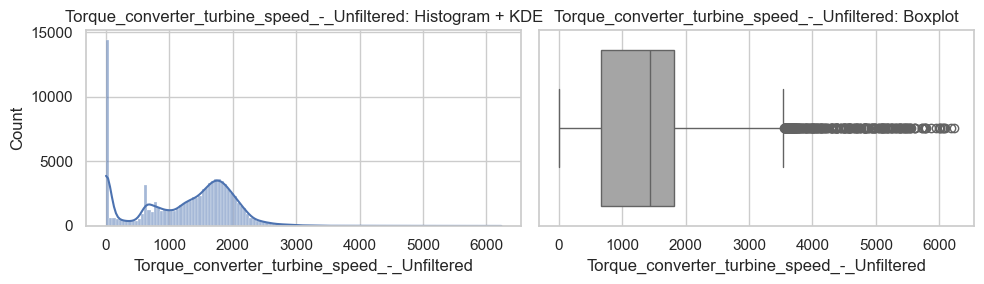

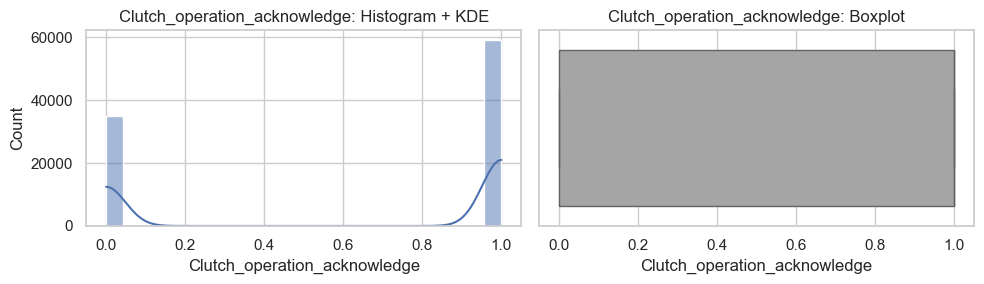

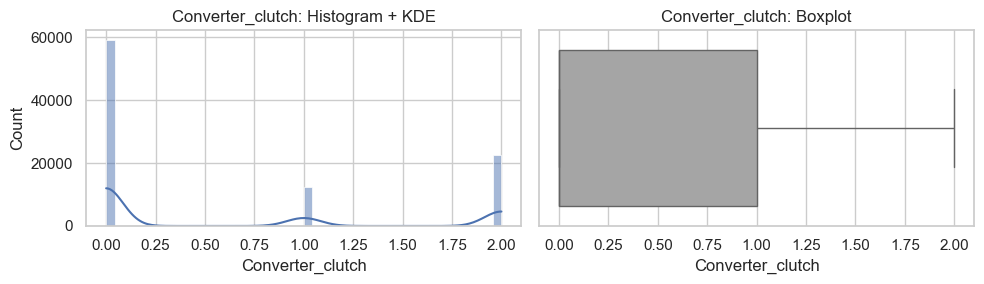

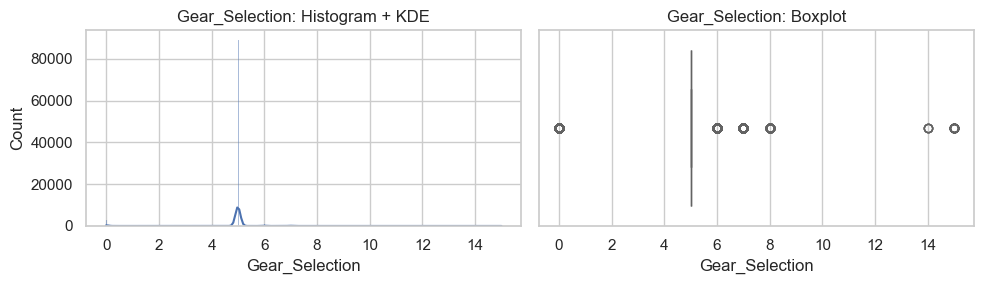

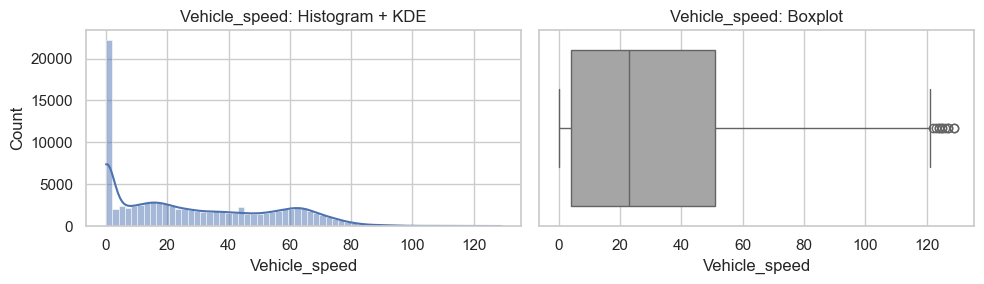

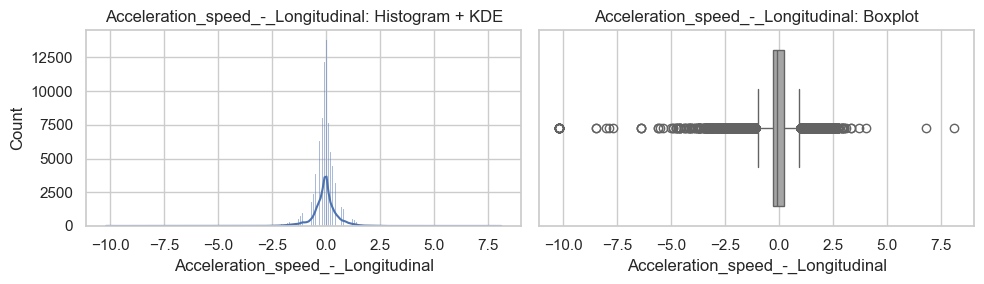

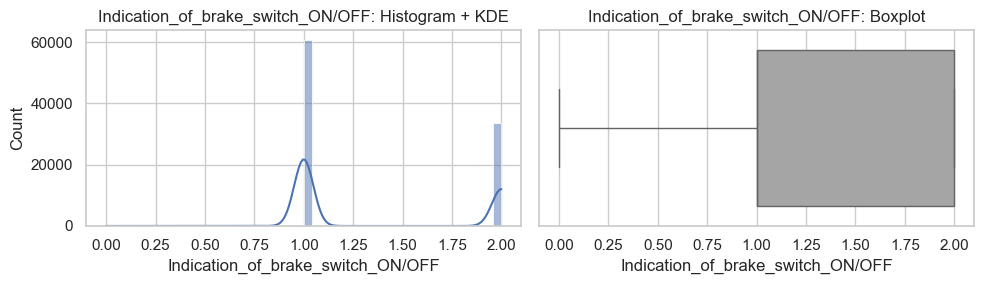

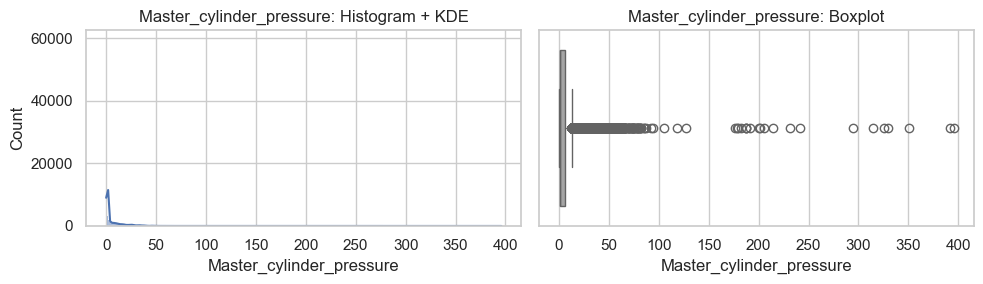

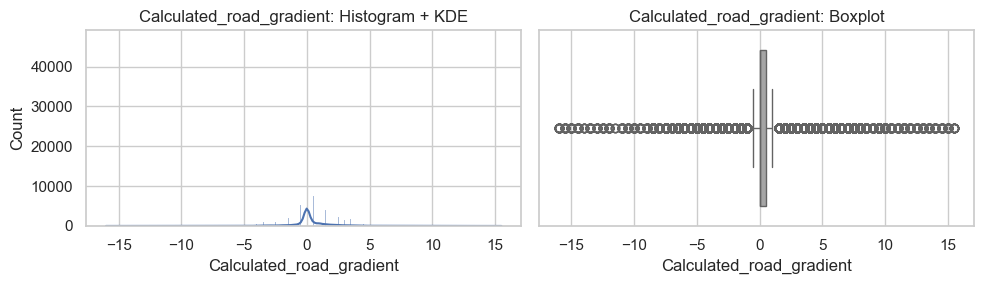

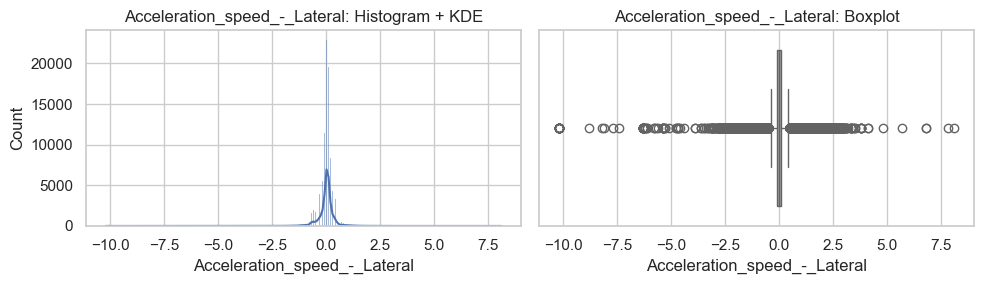

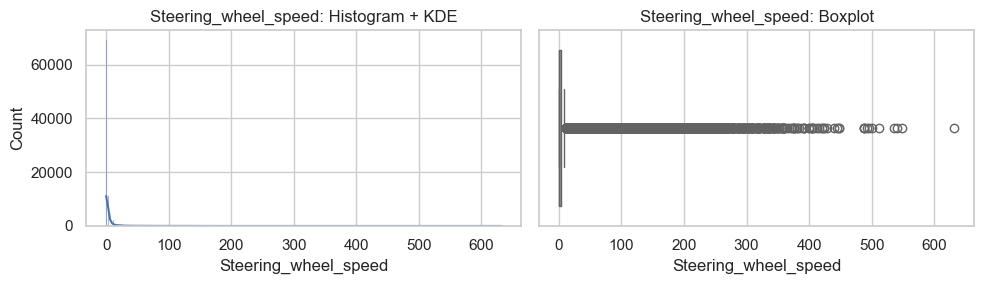

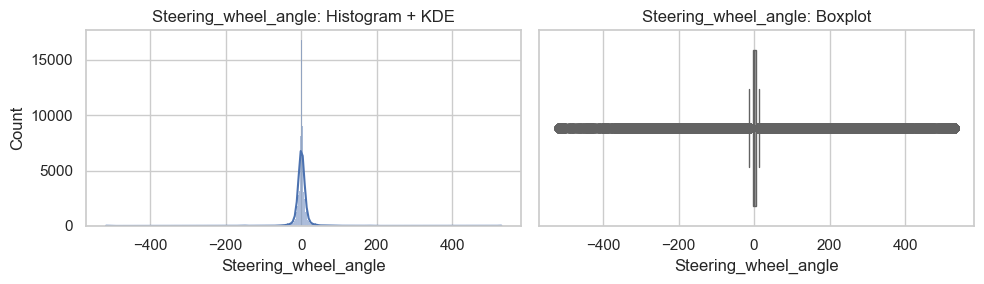

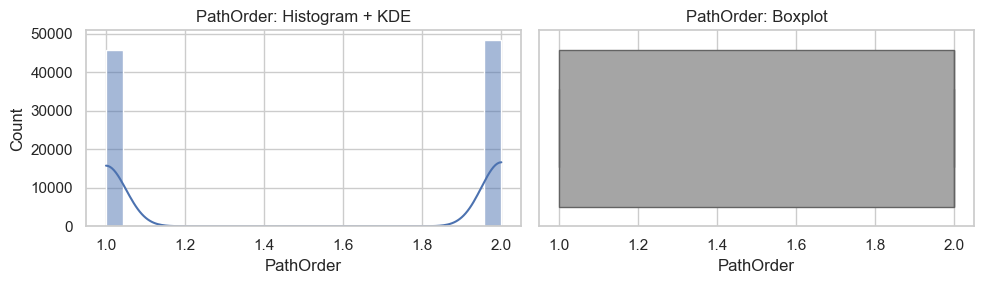

,count,mean,std,min,25%,50%,75%,max,skew,outlier_count,outlier_pct
Fuel_consumption,94380.0,757.000246,761.376214,0.0,320.0,422.40,1036.80,10931.2,2.896893,5363,5.682348
Accelerator_Pedal_value,94380.0,3.718682,8.505756,0.0,0.0,0.00,0.00,99.2,3.640442,23529,24.930070
Throttle_position_signal,94380.0,13.208186,16.262249,0.0,6.6,7.50,12.70,100.0,4.157294,7556,8.005933
Short_Term_Fuel_Trim_Bank1,94380.0,0.122782,3.166412,-15.6,-1.6,0.00,1.60,23.4,0.796784,4742,5.024370
Intake_air_pressure,94380.0,36.853433,27.957584,0.0,4.0,38.00,57.00,178.0,0.214383,49,0.051918
Filtered_Accelerator_Pedal_value,94380.0,0.000000,0.000000,0.0,0.0,0.00,0.00,0.0,0.000000,0,0.000000
Absolute_throttle_position,94380.0,19.362277,12.079046,12.5,14.5,15.30,19.20,84.3,4.141676,7393,7.833227
Engine_soacking_time,94380.0,26.795327,73.072712,0.0,1.0,3.00,6.00,255.0,2.715942,9208,9.756304
Inhibition_of_engine_fuel_cut_off,94380.0,0.000000,0.000000,0.0,0.0,0.00,0.00,0.0,0.000000,0,0.000000
Engine_in_fuel_cut_off,94380.0,0.067249,0.250455,0.0,0.0,0.00,0.00,1.0,3.455792,6347,6.724942


In [10]:
# Numeric features: histogram + KDE and boxplot
numeric_cols = [col for col in df_eda.select_dtypes(include=np.number).columns if col != 'Class' and col != 'Time(s)']

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df_eda[col], kde=True, ax=axes[0])
    axes[0].set_title(f'{col}: Histogram + KDE')
    sns.boxplot(x=df_eda[col], ax=axes[1], color='#A5A5A5')
    axes[1].set_title(f'{col}: Boxplot')
    plt.tight_layout()
    plt.show()

# Calculate outliers using IQR method for each column
def calculate_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((series < lower_bound) | (series > upper_bound)).sum()
    return outliers

outlier_counts = {col: calculate_outliers(df_eda[col]) for col in numeric_cols}
outlier_percentages = {col: (count / len(df_eda)) * 100 for col, count in outlier_counts.items()}

# Quick numeric summary to complement plots with outlier info
summary_table = df_eda[numeric_cols].describe().T.assign(
    skew=df_eda[numeric_cols].skew(),
    outlier_count=pd.Series(outlier_counts),
    outlier_pct=pd.Series(outlier_percentages)
)
display(summary_table)

KeyboardInterrupt: 

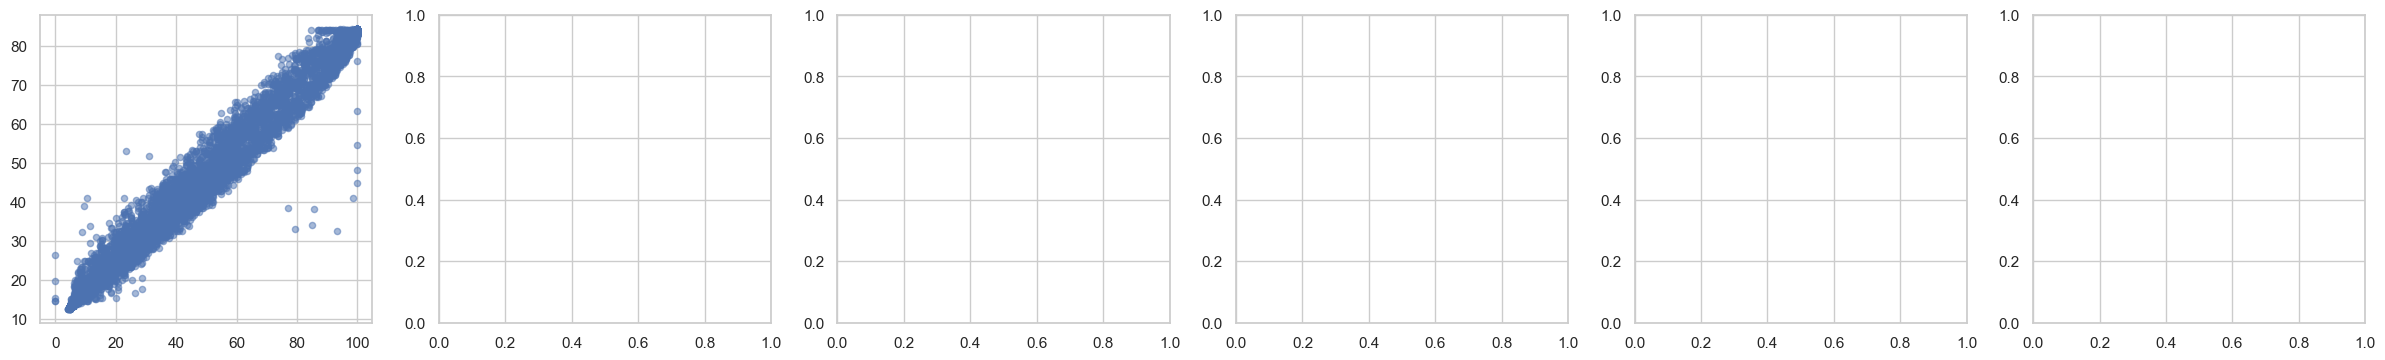

In [7]:

pairs = [
    # Throttle / pedal family
    ('Throttle_position_signal', 'Absolute_throttle_position'),          # ~1.00 (near-duplicate)

    # Torque / load family
    ('Engine_torque', 'Engine_torque_after_correction'),                # ~1.00 (near-duplicate)
    ('Engine_torque', 'Calculated_LOAD_value'),                         # ~0.92
    ('Engine_torque_after_correction', 'Calculated_LOAD_value'),         # ~0.92
    ('Engine_torque', 'Flywheel_torque'),                               # ~0.89
  
    # Engine speed vs torque indicator
    ('Engine_speed', 'Maximum_indicated_engine_torque'),                # ~0.95
]


# Check if all columns exist in df_eda
missing_cols = [col for pair in pairs for col in pair if col not in df_eda.columns]
if missing_cols:
    print(f"Missing columns in df_eda: {missing_cols}")
else:
    fig, axes = plt.subplots(1, len(pairs), figsize=(5*len(pairs), 4))
    for ax, (x, y) in zip(axes, pairs):
        sns.regplot(data=df_eda, x=x, y=y, scatter_kws={'s': 20, 'alpha': 0.5}, line_kws={'color': 'red'}, ax=ax)
        ax.set_title(f'{x} vs {y} (with trend line)')
    plt.tight_layout()
    plt.show()

In [14]:
num_df = df_eda.select_dtypes(include='number')
plt.figure(figsize=(60, 40))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (numeric features)')
plt.tight_layout()
plt.show()

NameError: name 'df_eda' is not defined

## now we can start with changing the data 
Remove non-informative features (closed to 0 var and same values features) cz they do give any usfule infos
Handle highly correlated features (we can use random forest that is good with correlation or keep one feature from ones that are very correlated)
Outlier handling
Feature scaling


# 🧹 Data Cleaning & Quality Assurance

This notebook implements comprehensive data cleaning following the lecture framework:
- **A) Duplicates**: Identify and remove duplicate records
- **B) Missing Values**: Handle NaN and invalid entries
- **C) Outliers**: Detect and manage anomalous values using statistical methods
- **D) Noise**: Smooth noisy data and handle data quality issues

**Output**: A cleaned dataset saved to `data/cleaned/` and a detailed change record.


## Initial Data Assessment

In [ ]:
print("="*80)
print("INITIAL DATA ASSESSMENT")
print("="*80)

print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst few rows:")
display(df.head(3))

## A) DUPLICATES - Identify and Remove Duplicate Records


In [ ]:



print("\n" + "="*80)
print("3A) DUPLICATES ANALYSIS")
print("="*80)

initial_rows = len(df)

# Check for complete duplicates (all columns identical)
complete_dupes = df.duplicated(keep=False).sum()
print(f"\n Complete Duplicates (all columns): {complete_dupes}")

if complete_dupes > 0:
    print("\nSample of complete duplicates:")
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(6))

# Check for duplicates considering key identifiers (exclude Time and PathOrder)
key_cols = [col for col in df.columns if col not in ['Time(s)', 'PathOrder']]
partial_dupes = df.duplicated(subset=key_cols, keep=False).sum()
print(f"\n Duplicates (excluding Time & PathOrder): {partial_dupes}")

# Remove complete duplicates (keep='first')
df_no_dupes = df.drop_duplicates(keep='first')
dupes_removed = initial_rows - len(df_no_dupes)
print(f"\n Duplicates removed: {dupes_removed}")
print(f"   Rows after deduplication: {len(df_no_dupes)}")
# which rows are duplicates ?
if dupes_removed > 0:
    print("\nSample of duplicates removed:")
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(6))
#  Duplicates in rows or colomns have been handled. ?
df = df_no_dupes
print("\n✓ Duplicate analysis and removal complete.")
print("="*80)


## No Dublicates , say less

## B) MISSING VALUES - Analyze and Handle NaN

In [ ]:
print("\n" + "="*80)
print("3B) MISSING VALUES ANALYSIS")
print("="*80)

# Count missing values
missing_count = df_no_dupes.isnull().sum()
missing_pct = (missing_count / len(df_no_dupes)) * 100
missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing_Count': missing_count.values,
    'Missing_%': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_%', ascending=False)

if len(missing_df) > 0:
    print(f"\nColumns with missing values ({len(missing_df)}):")
    display(missing_df)
else:
    print("\n✓ No missing values found!")

total_missing = df_no_dupes.isnull().sum().sum()
print(f"\nTotal missing values: {total_missing}")

# Create df_no_missing for next stage (no rows/columns dropped since no missing values)
df_no_missing = df_no_dupes.copy()
print(f"\n✓ Rows after missing value handling: {len(df_no_missing)}")

### No Missing data , hell yeah 

## C) OUTLIERS - Detect and Visualize

In [ ]:
print("\n" + "="*80)
print("3C) OUTLIERS DETECTION & ANALYSIS")
print("="*80)

# Get numeric columns (exclude Time, PathOrder, Class for now)

numeric_cols = df_no_missing.select_dtypes(include=[np.number]).columns.tolist()

exclude_cols = ['Time(s)', 'PathOrder']
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"\n Numeric columns for analysis: {len(numeric_cols)}")
print(numeric_cols[:10], "...")  # Show first 10

# Calculate outliers using IQR method
outlier_summary = []
for col in numeric_cols:
    Q1 = df_no_missing[col].quantile(0.25)
    Q3 = df_no_missing[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = (df_no_missing[col] < lower_bound) | (df_no_missing[col] > upper_bound)
    outlier_count = outlier_mask.sum()
    outlier_pct = (outlier_count / len(df_no_missing)) * 100
    
    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outlier_count,
        'Outlier_%': outlier_pct
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_%', ascending=False)
print("\n Top 10 columns with most outliers (IQR method):")
display(outlier_df.head(10))

In [ ]:
# Visualize top 6 features with highest outlier percentages
print("\nBoxplot visualizations for top outlier columns:")

top_outlier_cols = outlier_df.head(6)['Column'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(top_outlier_cols):
    sns.boxplot(y=df_no_missing[col], ax=axes[idx], color='lightblue')
    axes[idx].set_title(f'{col}\n(Outliers: {outlier_df[outlier_df["Column"]==col]["Outlier_%"].values[0]:.2f}%)')
    axes[idx].set_ylabel('Value')

plt.tight_layout()
plt.show()

print("✓ Boxplots generated for visual inspection")

In [ ]:
# Decision: Analyze outlier context
print("\n" + "-"*80)
print("OUTLIER HANDLING DECISION")
print("-"*80)

print("\nContext Analysis:")
print("   - Dataset: Driving data from 10 drivers")
print("   - Goal: Driving assessment and pattern discovery")
print("   - Consideration: Outliers could represent:")
print("       • Extreme driving behaviors (valid for analysis)")
print("       • Measurement errors/sensor noise (invalid)")
print("       • Different driving conditions (valid context)")

print("\nSTRATEGY: Use Winsorization (capping) instead of removal:")
print("   - Cap outliers at 95th/5th percentiles")
print("   - Preserves extreme but valid driving behaviors")
print("   - Reduces impact of potential measurement errors")
print("   - Maintains data for pattern discovery")

# Apply Winsorization (cap at 5th and 95th percentiles)
df_winsorized = df_no_missing.copy()
winsor_summary = []

for col in numeric_cols:
    p5 = df_winsorized[col].quantile(0.05)
    p95 = df_winsorized[col].quantile(0.95)
    
    values_below_p5 = (df_winsorized[col] < p5).sum()
    values_above_p95 = (df_winsorized[col] > p95).sum()
    values_capped = values_below_p5 + values_above_p95
    
    df_winsorized[col] = df_winsorized[col].clip(lower=p5, upper=p95)
    
    winsor_summary.append({
        'Column': col,
        'P5': p5,
        'P95': p95,
        'Capped_Below_P5': values_below_p5,
        'Capped_Above_P95': values_above_p95,
        'Total_Capped': values_capped
    })

winsor_df = pd.DataFrame(winsor_summary).sort_values('Total_Capped', ascending=False)
print("\nWinsorization applied:")
print(f"   Total values capped: {winsor_df['Total_Capped'].sum():,}")
print("\n   Top 5 columns with capped values:")
display(winsor_df[winsor_df['Total_Capped'] > 0].head(5))

* we used capping in order to reduce the effect of noise and outliers without deleting data m since they r our target here


## D) NOISE - Smooth and Validate Data Quality

In [ ]:
print("\n" + "="*80)
print("3D) NOISE REDUCTION & DATA QUALITY")
print("="*80)

df_cleaned = df_winsorized.copy()

# 1. Handle zero/constant values that might be noise
print("\nNoise Detection:")
print("   Checking for suspicious zero values and constant features...")

noise_report = []
for col in numeric_cols:
    zero_count = (df_cleaned[col] == 0).sum()
    zero_pct = (zero_count / len(df_cleaned)) * 100
    
    unique_values = df_cleaned[col].nunique()
    variance = df_cleaned[col].var()
    
    noise_report.append({
        'Column': col,
        'Zeros': zero_count,
        'Zero_%': zero_pct,
        'Unique_Values': unique_values,
        'Variance': variance
    })

noise_df = pd.DataFrame(noise_report).sort_values('Zero_%', ascending=False)

print("\n   Top columns with high zero values:")
display(noise_df[noise_df['Zero_%'] > 50].head(10))

print("\n   Columns with very low variance (near-constant):")
low_var = noise_df[noise_df['Variance'] < 0.1].sort_values('Variance')
display(low_var.head(10))

# Apply cleaning: drop near-constant columns
low_var_cols = low_var['Column'].tolist()
if low_var_cols:
    df_cleaned = df_cleaned.drop(columns=low_var_cols)
    numeric_cols = [c for c in numeric_cols if c not in low_var_cols]
    print(f"\n✓ Dropped low-variance columns: {low_var_cols}")
else:
    print("\n✓ No low-variance columns to drop")

# Drop specified zero-heavy features (do not replace)
zero_drop_cols = [
    'fuel pressure',
    'TCU_requested_engine_RPM_increase',
    'Glow_plug_control_request',
    'Inhibition_of_engine_fuel_cut_of',
    'Filtered_Accelerator_Pedal_value'
]
existing_zero_drop_cols = [c for c in zero_drop_cols if c in df_cleaned.columns]
if existing_zero_drop_cols:
    df_cleaned = df_cleaned.drop(columns=existing_zero_drop_cols)
    numeric_cols = [c for c in numeric_cols if c not in existing_zero_drop_cols]
    print(f"\n✓ Dropped specified zero-heavy columns: {existing_zero_drop_cols}")
else:
    print("\n✓ None of the specified zero-heavy columns were found")

In [ ]:
# 2. Detect near-duplicate columns (high correlation)
print("\nNear-Duplicate Features (High Correlation):")

# Calculate correlation matrix
corr_matrix = df_cleaned[numeric_cols].corr().abs()

# Find highly correlated pairs (excluding self-correlation)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.95:
            high_corr_pairs.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
    print(f"\n   Found {len(high_corr_df)} highly correlated pairs (>0.95):")
    display(high_corr_df)

    # Keep one feature per highly correlated pair (drop Feature_2)
    cols_to_drop = sorted(set(high_corr_df['Feature_2'].tolist()))
    df_cleaned = df_cleaned.drop(columns=cols_to_drop)
    numeric_cols = [c for c in numeric_cols if c not in cols_to_drop]
    print(f"\n✓ Dropped highly correlated features: {cols_to_drop}")
else:
    print("   No near-duplicate features found")

In [ ]:
# 4. Normalization (Min-Max Scaling)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_normalized = df_cleaned.copy()
df_normalized[numeric_cols] = scaler.fit_transform(df_normalized[numeric_cols])

df_cleaned = df_normalized
print("\n✓ Normalization applied (Min-Max scaling to [0, 1])")

In [ ]:
# 3. Data type validation
print("\n✓ Data Type & Format Validation:")
print(f"   Numeric columns: {len(numeric_cols)}")
print(f"   Object columns: {df_cleaned.select_dtypes(include='object').shape[1]}")

# Check for categorical data
categorical_cols = df_cleaned.select_dtypes(include='object').columns.tolist()
print(f"\n   Categorical columns: {categorical_cols}")
for col in categorical_cols:
    print(f"      - {col}: {df_cleaned[col].nunique()} unique values")
    print(f"        Values: {df_cleaned[col].unique().tolist()}")

## Data Quality Summary & Save Cleaned Data

In [ ]:
print("\n" + "="*80)
print("DATA CLEANING SUMMARY")
print("="*80)

print(f"\nBEFORE CLEANING:")
print(f"   Rows: {initial_rows:,}")
print(f"   Columns: {df.shape[1]}")
print(f"   Shape: {df.shape}")

print(f"\nCLEANING STEPS APPLIED:")
print(f"   1. Duplicates removed: {dupes_removed}")
print(f"   2. Missing values: Analyzed (no rows/cols dropped)")
print(f"   3. Outliers: Winsorized {winsor_df['Total_Capped'].sum():,} values")
print(f"   4. Noise: Detected high-correlation features and zero-heavy columns")

print(f"\nAFTER CLEANING:")
print(f"   Rows: {len(df_cleaned):,}")
print(f"   Columns: {df_cleaned.shape[1]}")
print(f"   Shape: {df_cleaned.shape}")
print(f"   Rows removed: {initial_rows - len(df_cleaned):,} ({((initial_rows - len(df_cleaned))/initial_rows)*100:.2f}%)")

print(f"\n✓ DATA QUALITY METRICS:")
print(f"   Missing values: {df_cleaned.isnull().sum().sum()} (0.00%)")
print(f"   Duplicates: {df_cleaned.duplicated().sum()}")
print(f"   Data types valid: ✓")

In [ ]:
print(f"\nSaving cleaned data...")
CLEANED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
df_cleaned.to_csv(CLEANED_DATA_PATH, index=False)
print(f"✓ Cleaned data saved to: {CLEANED_DATA_PATH}")
print(f"  File size: {CLEANED_DATA_PATH.stat().st_size / 1024 / 1024:.2f} MB")

In [ ]:
CHANGE_LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(CHANGE_LOG_PATH, 'w', encoding='utf-8') as f:
    f.write(change_log)

print(f"\n✓ Change log saved to: {CHANGE_LOG_PATH}")
print(f"\nTotal documentation created successfully!")

## Final Verification

In [ ]:
print("\n" + "="*80)
print("FINAL VERIFICATION")
print("="*80)

# Verify cleaned data
df_verify = pd.read_csv(CLEANED_DATA_PATH)
print(f"\nCleaned dataset verified:")
print(f"   Shape: {df_verify.shape}")
print(f"   Missing values: {df_verify.isnull().sum().sum()}")
print(f"   Duplicates: {df_verify.duplicated().sum()}")
print(f"\nFiles generated:")
print(f"   - {CLEANED_DATA_PATH}")
print(f"   - {CHANGE_LOG_PATH}")

print(f"\nDATA CLEANING COMPLETE!")
print(f"   Ready for feature engineering and modeling.")

df_verify.head()

## Dimensionality Reduction (PCA)
We apply PCA on the numeric features (excluding `Class` and `Time(s)` if present) to reduce dimensionality while preserving most variance.

Components for 95% variance: 18
Components for 99% variance: 23
Using n_components=18
PCA components retained: 18
Total variance retained: 0.9568


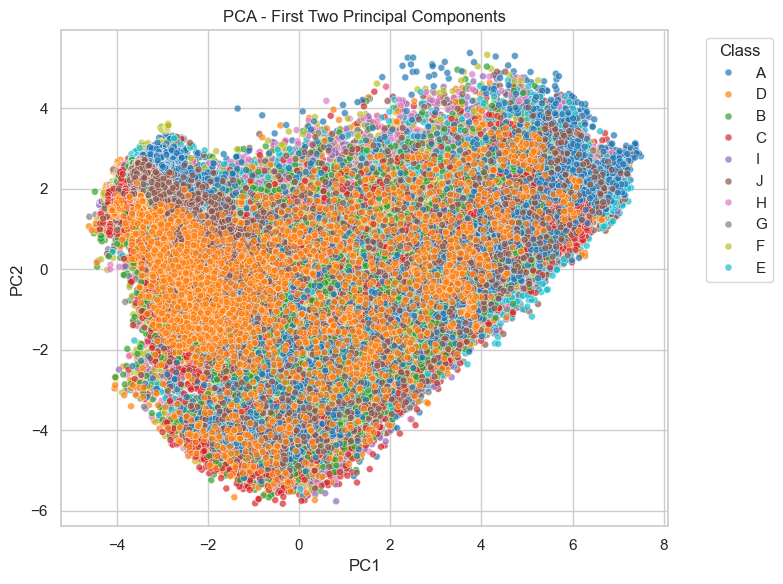

In [3]:
# Prepare data for PCA
df = pd.read_csv("../data/cleaned/Driving Data(KIA SOUL)_(150728-160714)_(10 Drivers_A-J)_cleaned.csv")

df.drop(columns=['Fuel_Pressure', 'TCU_requested_engine_RPM_increase', 'Glow_plug_control_request', 'Inhibition_of_engine_fuel_cut_of', 'Filtered_Accelerator_Pedal_value'], inplace=True, errors='ignore') 

pca_df = df.copy()

y = None
if 'Class' in pca_df.columns:
    y = pca_df['Class']

X = pca_df.select_dtypes(include='number')
X = X.drop(columns=['Class', 'Time(s)'], errors='ignore')

# Handle missing values (median imputation)
X = X.fillna(X.median(numeric_only=True))

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Variance rule: smallest n to explain ~95–99% variance
import numpy as np

pca_full = PCA()
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = int(np.argmax(cum_var >= 0.95) + 1)
n_99 = int(np.argmax(cum_var >= 0.99) + 1)
n_components_variance = n_95

print(f"Components for 95% variance: {n_95}")
print(f"Components for 99% variance: {n_99}")
print(f"Using n_components={n_components_variance}")

pca = PCA(n_components=n_components_variance)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
print(f"PCA components retained: {pca.n_components_}")
print(f"Total variance retained: {explained_var.sum():.4f}")

# Build PCA dataframe
pc_columns = [f"PC{i+1}" for i in range(X_pca.shape[1])]
pca_result_df = pd.DataFrame(X_pca, columns=pc_columns)

# Visualize first two components if available
if X_pca.shape[1] >= 2:
    plt.figure(figsize=(8, 6))
    if y is not None:
        sns.scatterplot(x=pca_result_df['PC1'], y=pca_result_df['PC2'], hue=y, palette='tab10', s=25, alpha=0.7)
        plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        sns.scatterplot(x=pca_result_df['PC1'], y=pca_result_df['PC2'], s=25, alpha=0.7)
    plt.title('PCA - First Two Principal Components')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.tight_layout()
    plt.show()

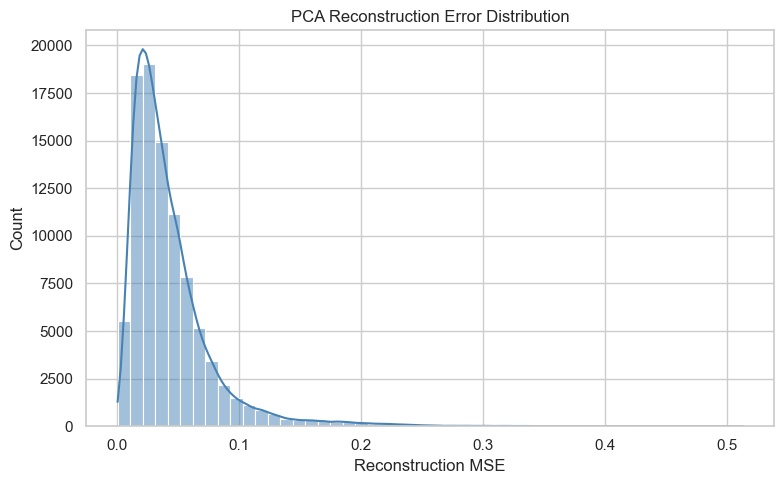

Reconstruction error: mean=0.043187, std=0.035237, max=0.512761


In [6]:
# Reconstruction error distribution (PCA)
X_reconstructed = pca.inverse_transform(X_pca)
recon_error = np.mean((X_scaled - X_reconstructed) ** 2, axis=1)

plt.figure(figsize=(8, 5))
sns.histplot(recon_error, bins=50, kde=True, color='steelblue')
plt.title('PCA Reconstruction Error Distribution')
plt.xlabel('Reconstruction MSE')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Reconstruction error: mean={recon_error.mean():.6f}, std={recon_error.std():.6f}, max={recon_error.max():.6f}")

In [9]:
# Validation rule: try 5, 10, 15, 20 components and compare anomaly rates
df = pd.read_csv("../data/transformed/Driving_Data_With_Risky_Label.csv")

df.drop(columns=['Fuel_Pressure', 'TCU_requested_engine_RPM_increase', 'Glow_plug_control_request', 'Inhibition_of_engine_fuel_cut_of', 'Filtered_Accelerator_Pedal_value'], inplace=True, errors='ignore') 

pca_df = df.copy()

X = pca_df.select_dtypes(include='number')
X = X.drop(columns=['Class', 'Time(s)' , 'risky'], errors='ignore')

# Handle missing values (median imputation)
X = X.fillna(X.median(numeric_only=True))

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

component_grid = [5, 10, 15, 20]
validation_results = []

for n_components in component_grid:
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    iso = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
    iso_labels = iso.fit_predict(X_pca)
    iso_anomaly_rate = (iso_labels == -1).mean()

    ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.02)
    svm_labels = ocsvm.fit_predict(X_pca)
    svm_anomaly_rate = (svm_labels == -1).mean()

    validation_results.append({
        'n_components': n_components,
        'iso_anomaly_pct': iso_anomaly_rate * 100,
        'svm_anomaly_pct': svm_anomaly_rate * 100
    })

validation_df = pd.DataFrame(validation_results)
print(validation_df)

   n_components  iso_anomaly_pct  svm_anomaly_pct
0             5         2.000424         1.998305
1            10         2.000424         2.001483
2            15         2.000424         2.006781
3            20         2.000424         2.000424


## Anomaly Detection (Isolation Forest)
We use Isolation Forest on standardized numeric features (excluding `Class` and `Time(s)`) to flag potential anomalies.

Test anomalies detected: 409 (2.17%)
Accuracy: 0.753
Precision: 0.853 | Recall: 0.070 | F1: 0.130
              precision    recall  f1-score   support

      Normal       0.75      1.00      0.86     13924
       Risky       0.85      0.07      0.13      4952

    accuracy                           0.75     18876
   macro avg       0.80      0.53      0.49     18876
weighted avg       0.78      0.75      0.67     18876



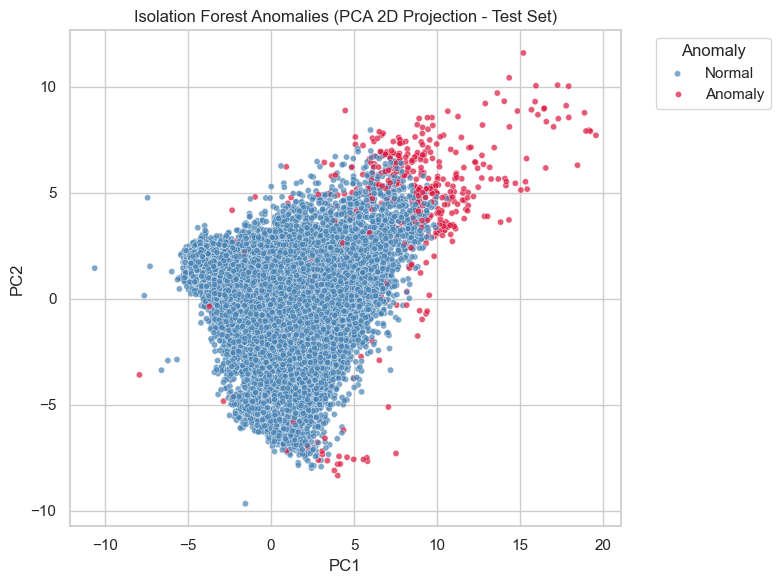

In [21]:
# Prepare data for Isolation Forest
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
df = pd.read_csv(TRANSFORMED_DATA_PATH)
iso_df = df.copy()

y_iso = None
if 'Class' in iso_df.columns:
    y_iso = iso_df['Class']

X_iso = iso_df.select_dtypes(include='number')
X_iso = X_iso.drop(columns=['Class', 'Time(s)', 'risky'], errors='ignore')

# Handle missing values (median imputation)
X_iso = X_iso.fillna(X_iso.median(numeric_only=True))

y_risky = iso_df['risky'] if 'risky' in iso_df.columns else None

# Train/test split (80/20)
X_iso_train, X_iso_test, y_train, y_test = train_test_split(
    X_iso,
    y_risky,
    test_size=0.2,
    random_state=42,
    stratify=y_risky if y_risky is not None else None
)

# Standardize features (fit on train, apply to test)
scaler_iso = StandardScaler()
X_iso_train_scaled = scaler_iso.fit_transform(X_iso_train)
X_iso_test_scaled = scaler_iso.transform(X_iso_test)

# Isolation Forest (fit on train, evaluate on test)
iso = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
iso.fit(X_iso_train_scaled)
iso_labels_test = iso.predict(X_iso_test_scaled)

# -1 = anomaly, 1 = normal
iso_test = iso_df.loc[X_iso_test.index].copy()
iso_test['is_anomaly'] = iso_labels_test
anomaly_count = (iso_test['is_anomaly'] == -1).sum()
print(f"Test anomalies detected: {anomaly_count} ({anomaly_count / len(iso_test) * 100:.2f}%)")

# Evaluate against risky label if available
if y_test is not None:
    y_true = (y_test == 1).astype(int)
    y_pred = (iso_labels_test == -1).astype(int)
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Risky'], zero_division=0))

# Visualize anomalies using first two PCA components for 2D view (test set)
pca_vis = PCA(n_components=2)
iso_2d = pca_vis.fit_transform(X_iso_test_scaled)
iso_plot = pd.DataFrame(iso_2d, columns=['PC1', 'PC2'], index=X_iso_test.index)
iso_plot['is_anomaly'] = iso_test['is_anomaly'].values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=iso_plot,
    x='PC1',
    y='PC2',
    hue='is_anomaly',
    palette={1: 'steelblue', -1: 'crimson'},
    alpha=0.7,
    s=20
)
plt.title('Isolation Forest Anomalies (PCA 2D Projection - Test Set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Anomaly', labels=['Normal', 'Anomaly'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

One-Class SVM test anomalies: 396 (2.10%)
Accuracy: 0.749
Precision: 0.765 | Recall: 0.061 | F1: 0.113
              precision    recall  f1-score   support

      Normal       0.75      0.99      0.85     13924
       Risky       0.77      0.06      0.11      4952

    accuracy                           0.75     18876
   macro avg       0.76      0.53      0.48     18876
weighted avg       0.75      0.75      0.66     18876



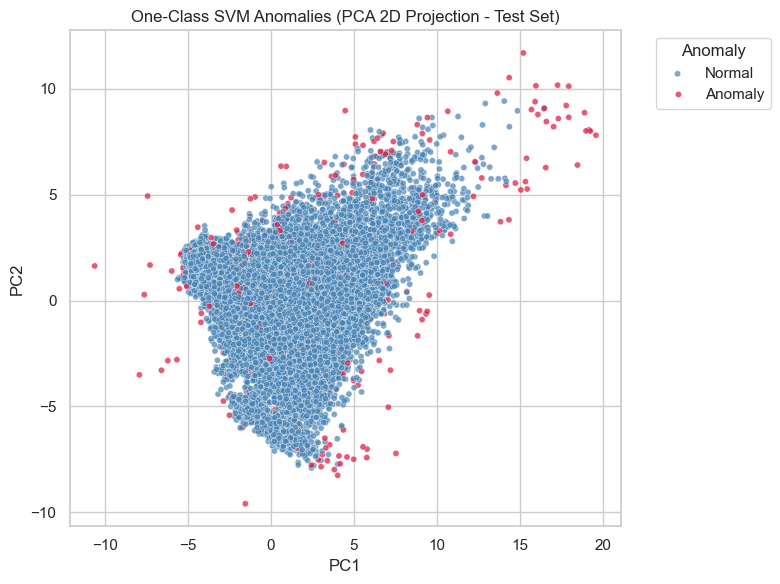

In [12]:
# One-Class SVM (Anomaly Detection)
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

svm_df = df.copy()

X_svm = svm_df.select_dtypes(include='number')
X_svm = X_svm.drop(columns=['Class', 'Time(s)'], errors='ignore')
X_svm = X_svm.fillna(X_svm.median(numeric_only=True))

y_risky = svm_df['risky'] if 'risky' in svm_df.columns else None

# Train/test split (80/20)
X_svm_train, X_svm_test, y_train, y_test = train_test_split(
    X_svm,
    y_risky,
    test_size=0.2,
    random_state=42,
    stratify=y_risky if y_risky is not None else None
)

# Standardize features (fit on train, apply to test)
scaler_svm = StandardScaler()
X_svm_train_scaled = scaler_svm.fit_transform(X_svm_train)
X_svm_test_scaled = scaler_svm.transform(X_svm_test)

ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.02)
ocsvm.fit(X_svm_train_scaled)
svm_labels_test = ocsvm.predict(X_svm_test_scaled)

# -1 = anomaly, 1 = normal
svm_test = svm_df.loc[X_svm_test.index].copy()
svm_test['is_anomaly_svm'] = svm_labels_test
svm_anomaly_count = (svm_test['is_anomaly_svm'] == -1).sum()
print(f"One-Class SVM test anomalies: {svm_anomaly_count} ({svm_anomaly_count / len(svm_test) * 100:.2f}%)")

# Evaluate against risky label if available
if y_test is not None:
    y_true = (y_test == 1).astype(int)
    y_pred = (svm_labels_test == -1).astype(int)
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Risky'], zero_division=0))

# Visualize anomalies using first two PCA components for 2D view (test set)
pca_vis_svm = PCA(n_components=2)
svm_2d = pca_vis_svm.fit_transform(X_svm_test_scaled)
svm_plot = pd.DataFrame(svm_2d, columns=['PC1', 'PC2'], index=X_svm_test.index)
svm_plot['is_anomaly'] = svm_test['is_anomaly_svm'].values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=svm_plot,
    x='PC1',
    y='PC2',
    hue='is_anomaly',
    palette={1: 'steelblue', -1: 'crimson'},
    alpha=0.7,
    s=20
)
plt.title('One-Class SVM Anomalies (PCA 2D Projection - Test Set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Anomaly', labels=['Normal', 'Anomaly'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [25]:
# Random Forest (Supervised) using risky label
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
df = pd.read_csv(TRANSFORMED_DATA_PATH)
rf_df = df.copy()

if 'risky' not in rf_df.columns:
    raise ValueError("'risky' column not found. Load ../data/transformed/Driving_Data_With_Risky_Label.csv first.")

X_rf = rf_df.select_dtypes(include='number')
X_rf = X_rf.drop(columns=['Class', 'Time(s)' , 'risky'] , errors='ignore')
X_rf = X_rf.fillna(X_rf.median(numeric_only=True))

y_rf = rf_df['risky'].astype(int)

# Train/test split (80/20)
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    random_state=42,
    stratify=y_rf
)

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_rf_train, y_rf_train)
y_rf_pred = rf.predict(X_rf_test)

acc = accuracy_score(y_rf_test, y_rf_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_rf_test, y_rf_pred, average='binary', zero_division=0)
print(f"Random Forest Accuracy: {acc:.3f}")
print(f"Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")
print(classification_report(y_rf_test, y_rf_pred, target_names=['Normal', 'Risky'], zero_division=0))

# Feature importance (top 10)
importances = pd.Series(rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)
print("Top 10 feature importances:")
display(importances.head(10))

Random Forest Accuracy: 0.964
Precision: 0.942 | Recall: 0.920 | F1: 0.931
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98     13924
       Risky       0.94      0.92      0.93      4952

    accuracy                           0.96     18876
   macro avg       0.96      0.95      0.95     18876
weighted avg       0.96      0.96      0.96     18876

Top 10 feature importances:


Master_cylinder_pressure             0.176500
Acceleration_speed_-_Longitudinal    0.133329
Wheel_velocity_front_left-hand       0.120511
Steering_wheel_angle                 0.116956
Steering_wheel_speed                 0.110028
Engine_Idel_Target_Speed             0.042793
Current_Gear                         0.040595
Torque_converter_speed               0.033423
Engine_speed                         0.029292
Engine_torque_after_correction       0.019489
dtype: float64